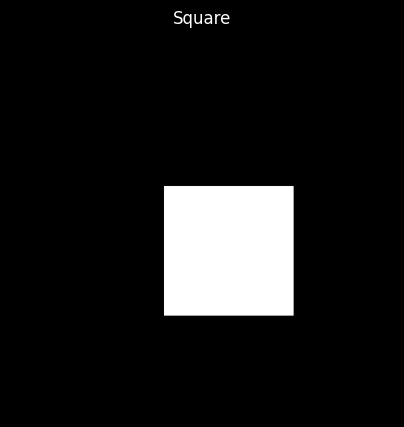

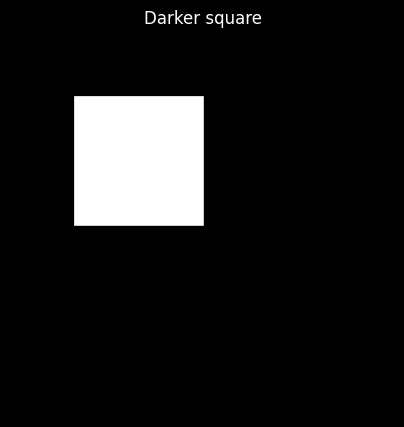

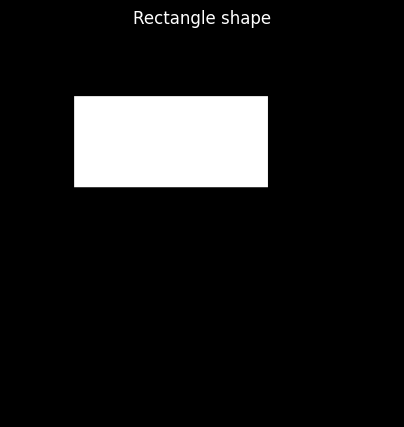

In [2]:
#task - topic 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()
# Basic tasks
img_square = np.zeros((300,300), dtype=np.uint8)
cv2.rectangle(img_square, (120,120), (220,220), 255, -1)
show(img_square, "Square")

img2 = np.zeros((300,300), dtype=np.uint8)
cv2.rectangle(img2, (50,50), (150,150), 120, -1)
show(img2, "Darker square")

img3 = np.zeros((300,300), dtype=np.uint8)
cv2.rectangle(img3, (50,50), (200,120), 255, -1)
show(img3, "Rectangle shape")


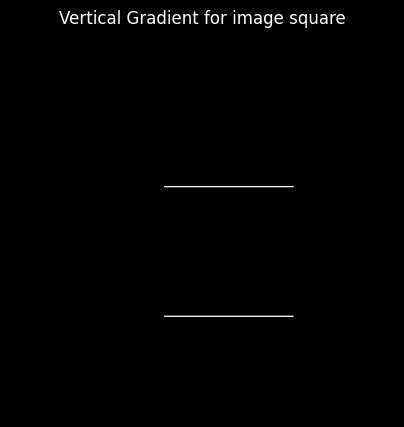

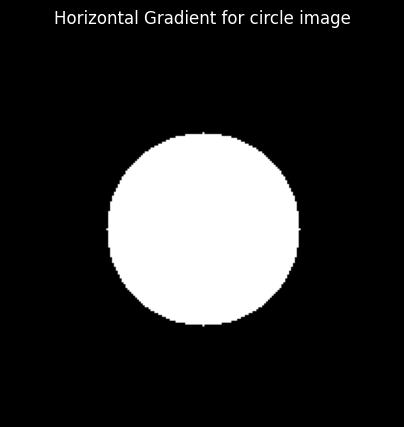

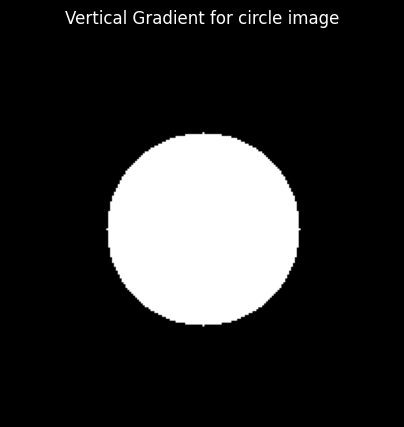

In [3]:
#Intermediate tasks
kernel_y = np.array([[-1], [1]], dtype=np.float32)
grad_y = cv2.filter2D(img_square, cv2.CV_64F, kernel_y)
show(np.abs(grad_y), "Vertical Gradient for image square")

kernel_x = np.array([[-1, 1]], dtype=np.float32)
kernel_y = np.array([[-1], [1]], dtype=np.float32)
img_circle = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img_circle, (100, 100), 50, 255, -1)
grad_x_circle = cv2.filter2D(img_circle.astype(np.float32), -1, cv2.CV_64F, kernel_x)
grad_y_circle = cv2.filter2D(img_circle.astype(np.float32), -1, cv2.CV_64F, kernel_y)

noise = np.random.randint(0, 30, img_square.shape, dtype=np.uint8)
noisy_img = cv2.add(img_square, noise)


show(np.abs(grad_x_circle), "Horizontal Gradient for circle image")
show(np.abs(grad_y_circle), "Vertical Gradient for circle image")

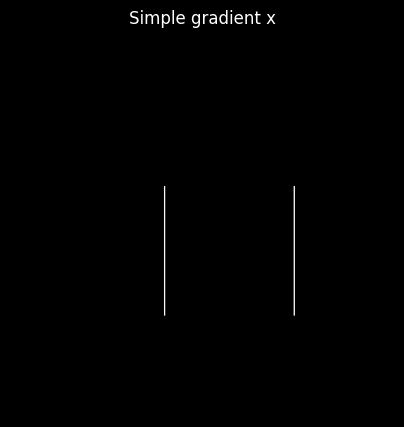

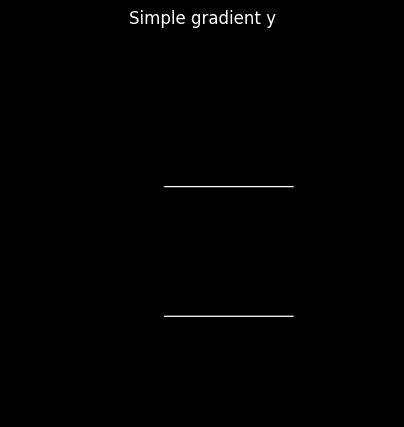

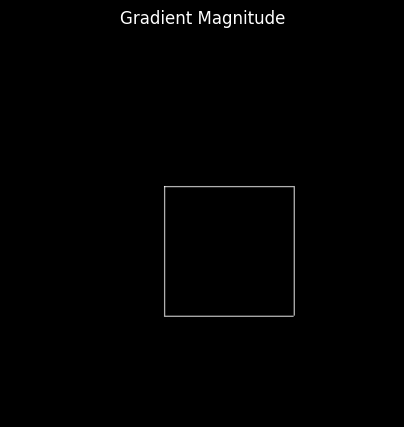

In [7]:
#Challenging tasks
def simple_gradient(image, direction='x'):

    if direction == 'x':
        kernel = np.array([[-1, 1]], dtype=np.float32)
    elif direction == 'y':
        kernel = np.array([[-1], [1]], dtype=np.float32)
    else:
        raise ValueError("Direction must be 'x' or 'y'")

    gradient = cv2.filter2D(image.astype(np.float32), -1, kernel)

    return gradient

grad_x = simple_gradient(img_square, 'x')
grad_y = simple_gradient(img_square, 'y')

magnitude = np.sqrt(grad_x**2 + grad_y**2)

show(np.abs(grad_x), "Simple gradient x")
show(np.abs(grad_y), "Simple gradient y")
show(magnitude, "Gradient Magnitude")

# Edge is a location in an image where the pixel intensity changes sharply. It usually represents the boundary between two different regions, for example the border between a black background and a white object. Gradients are used to detect edges because they measure how much the pixel intensity changes between neighboring pixels. When the change in intensity is large, the gradient value becomes large, which indicates the presence of an edge. Absolute values are often used when displaying gradients because gradient calculations can produce both positive and negative values depending on the direction of change. Taking the absolute value shows the strength of the change regardless of direction, making edges easier to visualize.

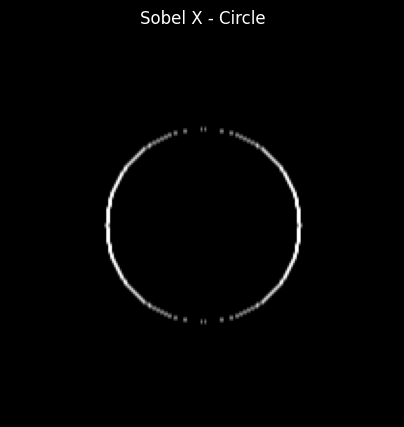

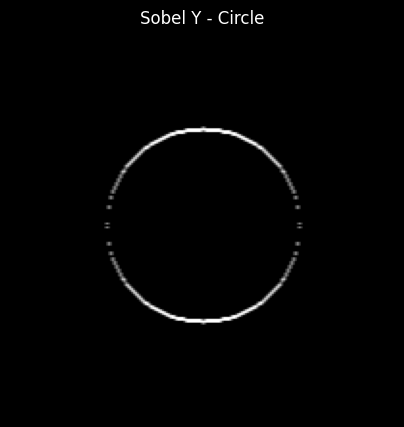

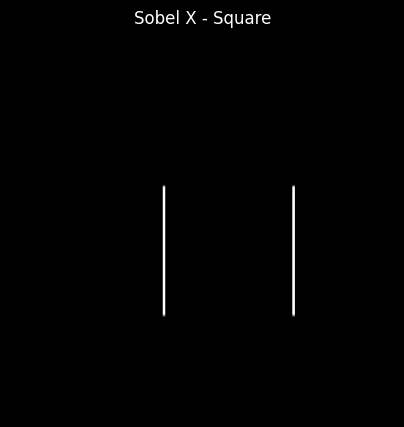

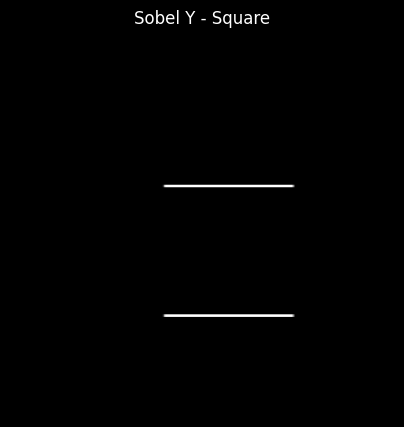

In [29]:
# task - topic 2
#Basic tasks
# i applied sobel for circle image
sobel_circle_x = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=3)
sobel_circle_y = cv2.Sobel(img_circle, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_circle_x), "Sobel X - Circle")
show(np.abs(sobel_circle_y), "Sobel Y - Circle")

# i applied sobel for square image
sobel_square_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_square_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_square_x), "Sobel X - Square")
show(np.abs(sobel_square_y), "Sobel Y - Square")

# here, i changed ksize
sobel_circle_3 = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=3)
sobel_circle_5 = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=5)

show(np.abs(sobel_circle_3), "Sobel ksize=3")
show(np.abs(sobel_circle_5), "Sobel ksize=5")


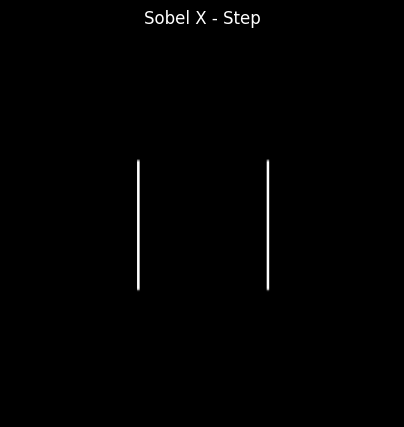

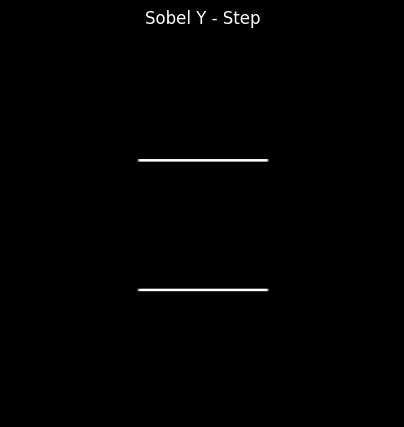

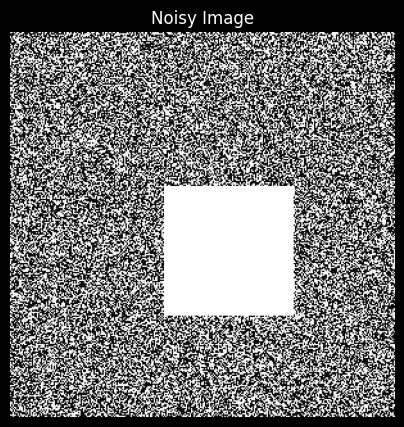

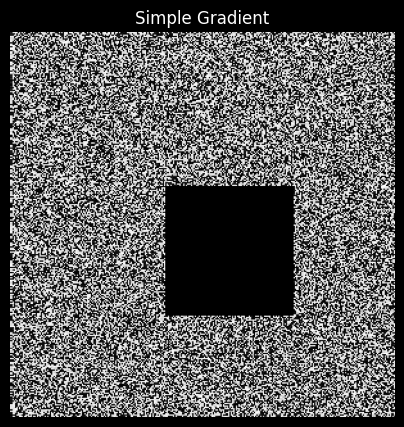

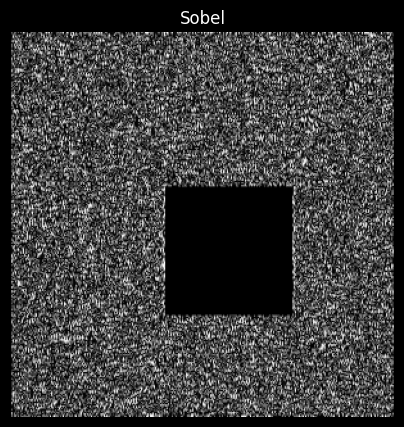

In [8]:
#Intermediate tasks
img_step = np.zeros((300,300), dtype=np.uint8)
cv2.rectangle(img_step, (100,100), (200,200), 255, -1)

sobel_step_x = cv2.Sobel(img_step, cv2.CV_64F, 1, 0, ksize=3)
sobel_step_y = cv2.Sobel(img_step, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_step_x), "Sobel X - Step")
show(np.abs(sobel_step_y), "Sobel Y - Step")

#noise
noise = np.random.normal(0, 20, img_square.shape).astype(np.uint8)
noisy_img = cv2.add(img_square, noise)

simple_grad = cv2.filter2D(noisy_img, cv2.CV_64F, np.array([[-1,1]]))
sobel_noise = cv2.Sobel(noisy_img, cv2.CV_64F, 1, 0, ksize=3)

show(noisy_img, "Noisy Image")
show(np.abs(simple_grad), "Simple Gradient")
show(np.abs(sobel_noise), "Sobel")

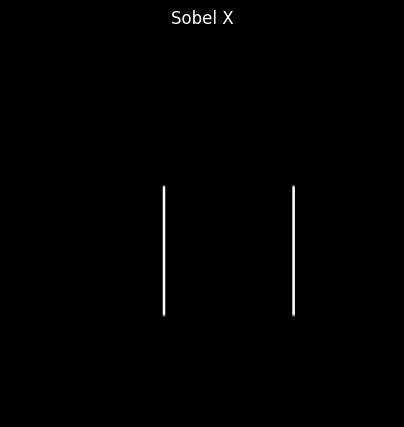

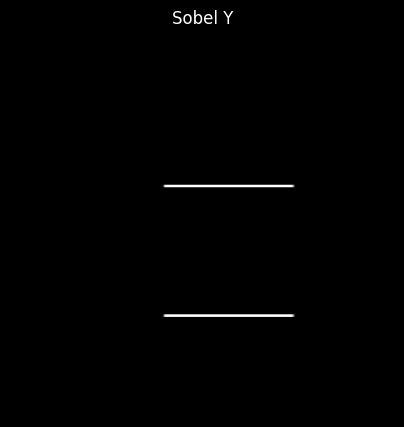

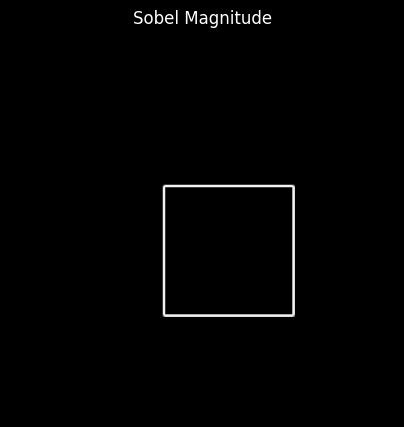

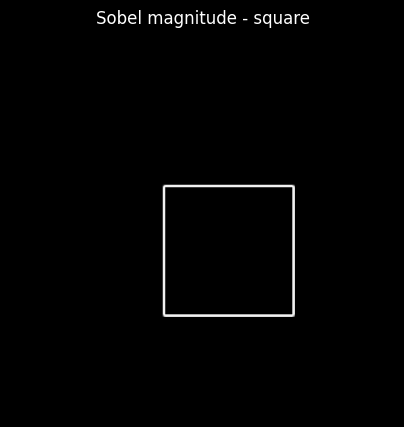

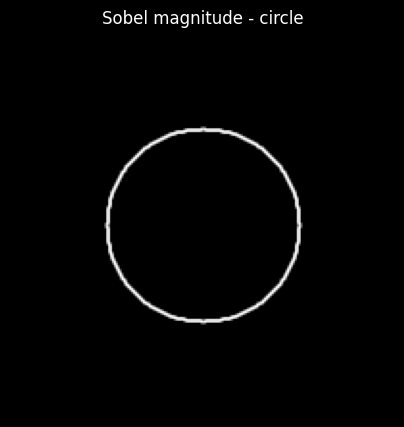

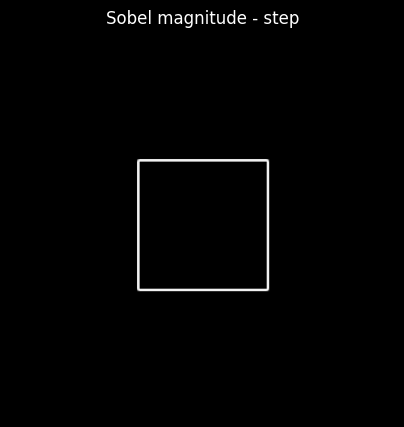

In [9]:
#Challenging tasks
def sobel_edges(image, ksize=3):

    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)

    magnitude1 = np.sqrt(gx ** 2 + gy ** 2)

    return gx, gy, magnitude1

gx, gy, sobel_mag = sobel_edges(img_square)

show(np.abs(gx), "Sobel X")
show(np.abs(gy), "Sobel Y")
show(sobel_mag, "Sobel Magnitude")

images = {
    "square": img_square,
    "circle": img_circle,
    "step": img_step
}

for name, img in images.items():
    gx, gy, mag = sobel_edges(img)
    show(mag, f"Sobel magnitude - {name}")



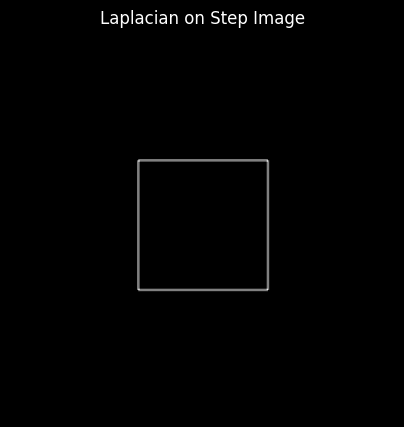

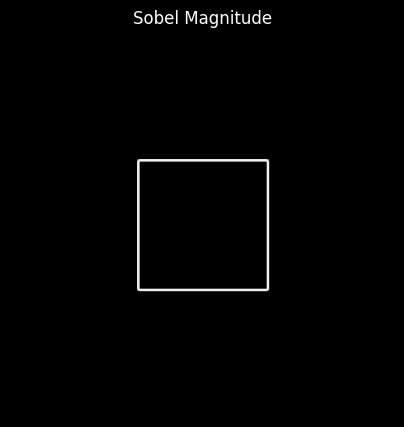

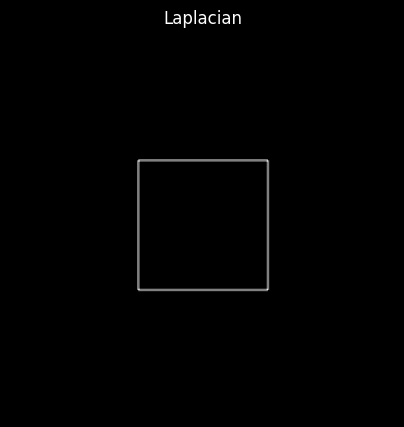

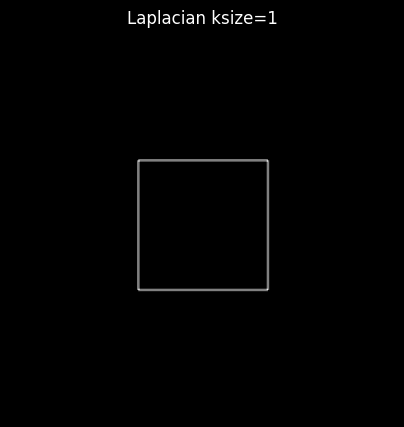

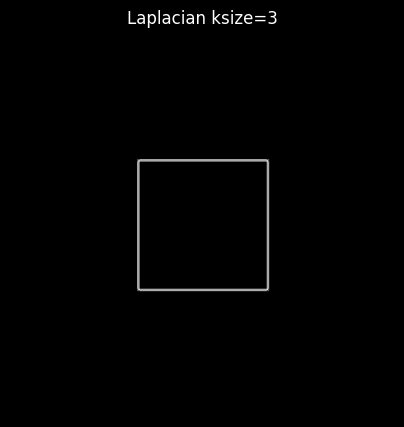

In [10]:
# task - topic 2
#Basic tasks
lap = cv2.Laplacian(img_step, cv2.CV_64F)

show(np.abs(lap), "Laplacian on Step Image")

sobel_x = cv2.Sobel(img_step, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_step, cv2.CV_64F, 0, 1, ksize=3)

sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

show(np.abs(sobel_mag), "Sobel Magnitude")

lap = cv2.Laplacian(img_step, cv2.CV_64F)

show(np.abs(lap), "Laplacian")

lap1 = cv2.Laplacian(img_step, cv2.CV_64F, ksize=1)
lap3 = cv2.Laplacian(img_step, cv2.CV_64F, ksize=3)

show(np.abs(lap1), "Laplacian ksize=1")
show(np.abs(lap3), "Laplacian ksize=3")

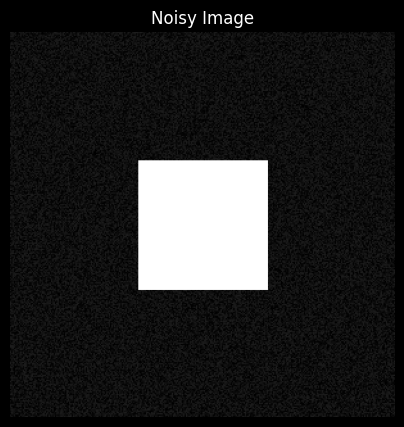

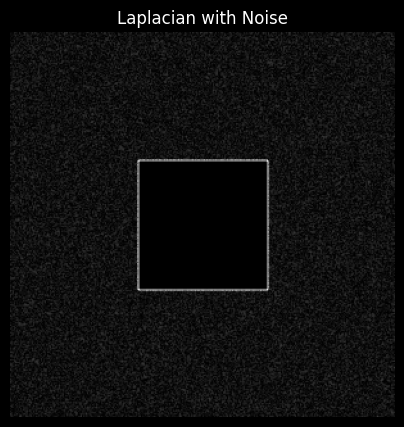

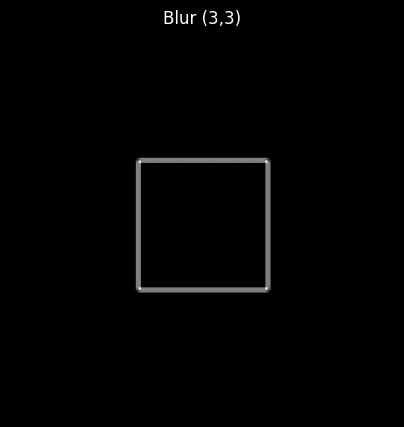

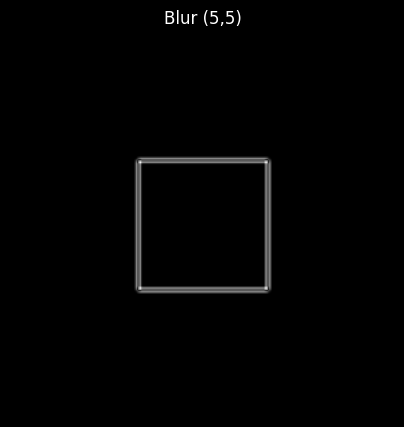

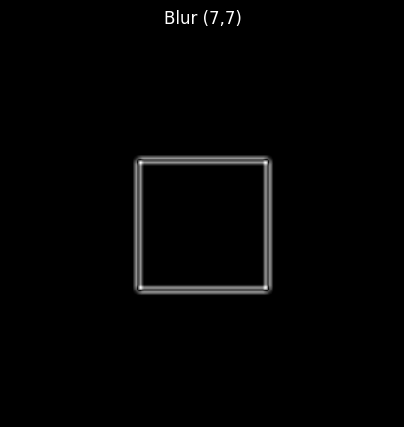

In [11]:
# Intermediate Tasks
noise = np.random.randint(0, 30, img_step.shape, dtype=np.uint8)
noisy_img = cv2.add(img_step, noise)

lap_noise = cv2.Laplacian(noisy_img, cv2.CV_64F)

show(noisy_img, "Noisy Image")
show(np.abs(lap_noise), "Laplacian with Noise")

blur3 = cv2.GaussianBlur(img_step, (3,3), 0)
blur5 = cv2.GaussianBlur(img_step, (5,5), 0)
blur7 = cv2.GaussianBlur(img_step, (7,7), 0)

lap3 = cv2.Laplacian(blur3, cv2.CV_64F)
lap5 = cv2.Laplacian(blur5, cv2.CV_64F)
lap7 = cv2.Laplacian(blur7, cv2.CV_64F)

show(np.abs(lap3), "Blur (3,3)")
show(np.abs(lap5), "Blur (5,5)")
show(np.abs(lap7), "Blur (7,7)")

Edges before blur: 804
Edges after blur: 2420


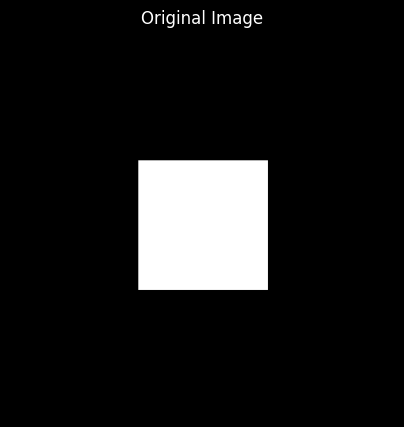

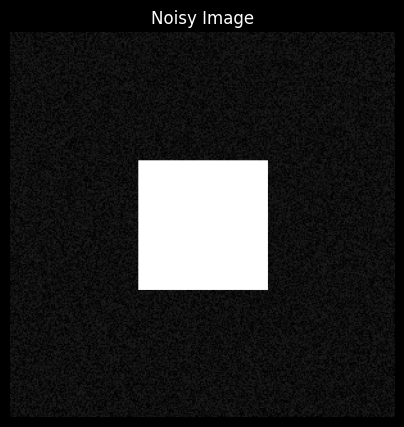

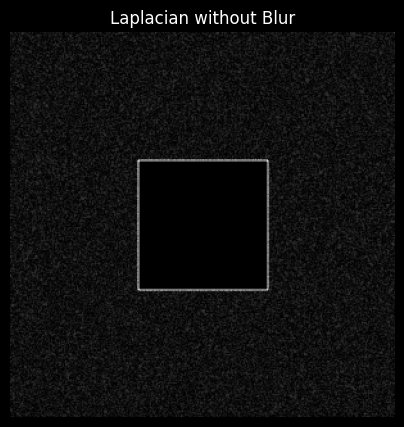

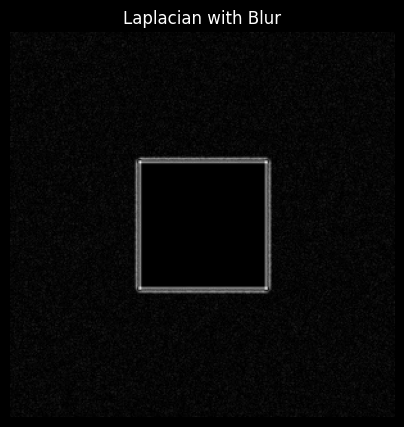

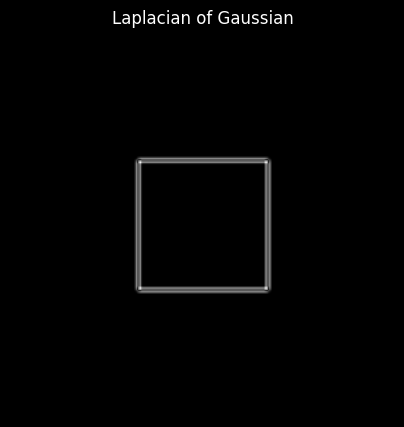

In [12]:
# Challenging Tasks
lap = cv2.Laplacian(img_step, cv2.CV_64F)
edges_before = np.count_nonzero(lap)

blur = cv2.GaussianBlur(img_step, (5,5), 0)
lap_blur = cv2.Laplacian(blur, cv2.CV_64F)
edges_after = np.count_nonzero(lap_blur)

print("Edges before blur:", edges_before)
print("Edges after blur:", edges_after)

noise = np.random.randint(0, 30, img_step.shape, dtype=np.uint8)
noisy_img = cv2.add(img_step, noise)

lap_no_blur = cv2.Laplacian(noisy_img, cv2.CV_64F)

blur = cv2.GaussianBlur(noisy_img, (5,5), 0)
lap_blur = cv2.Laplacian(blur, cv2.CV_64F)

show(img_step, "Original Image")
show(noisy_img, "Noisy Image")
show(np.abs(lap_no_blur), "Laplacian without Blur")
show(np.abs(lap_blur), "Laplacian with Blur")

blur = cv2.GaussianBlur(img_step, (5,5), 0)

log_result = cv2.Laplacian(blur, cv2.CV_64F)

show(np.abs(log_result), "Laplacian of Gaussian")

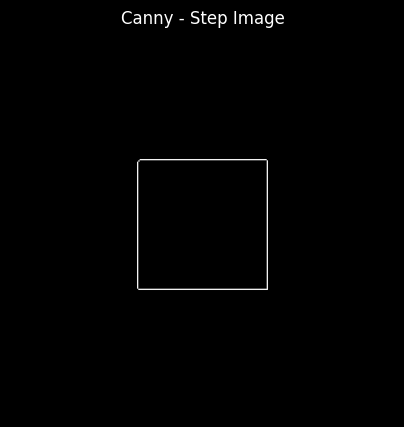

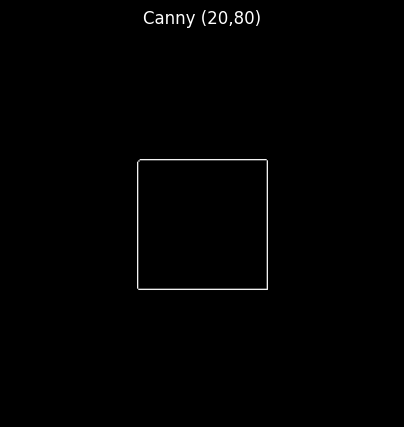

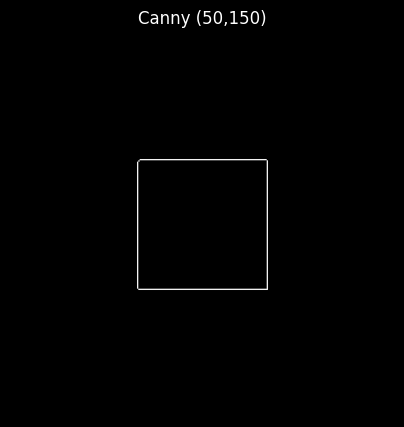

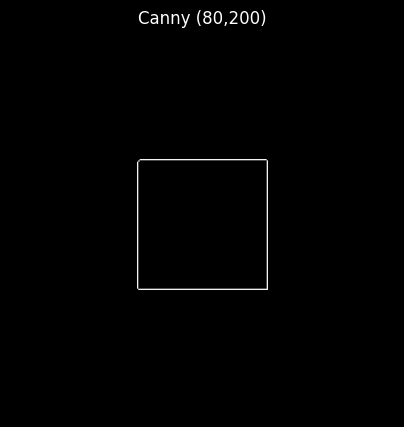

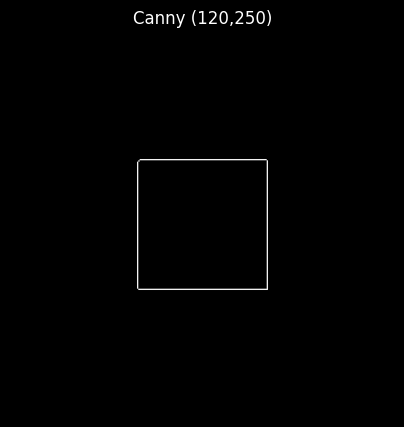

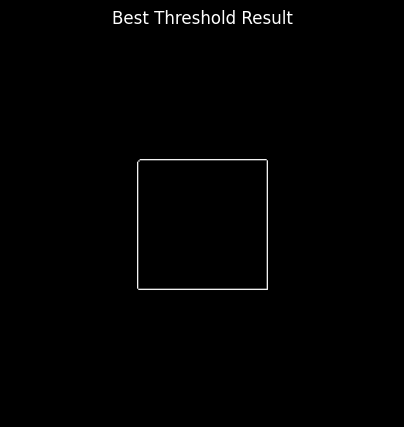

In [13]:
#task - topic 4
#Basic Tasks
edges = cv2.Canny(img_step, 50, 150)
show(edges, "Canny - Step Image")

edges1 = cv2.Canny(img_step, 20, 80)
edges2 = cv2.Canny(img_step, 50, 150)
edges3 = cv2.Canny(img_step, 80, 200)
edges4 = cv2.Canny(img_step, 120, 250)

show(edges1, "Canny (20,80)")
show(edges2, "Canny (50,150)")
show(edges3, "Canny (80,200)")
show(edges4, "Canny (120,250)")

best_edges = cv2.Canny(img_step, 50, 150)
show(best_edges, "Best Threshold Result")

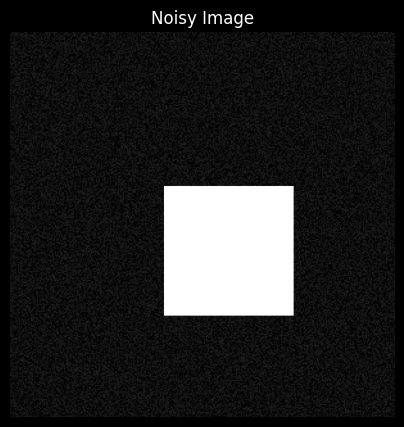

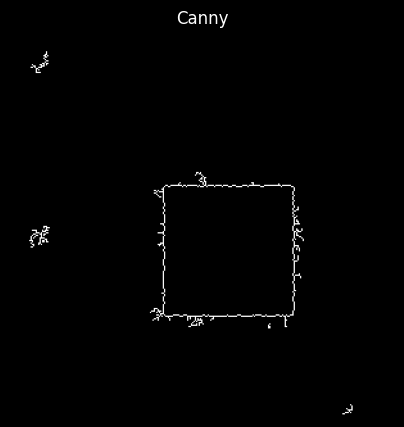

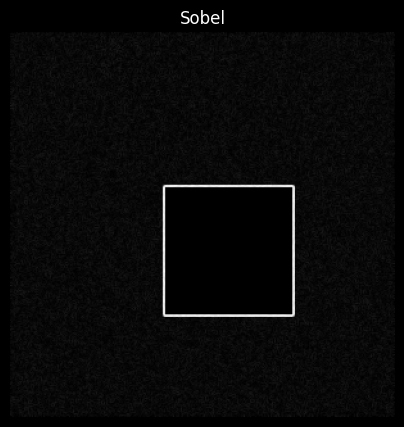

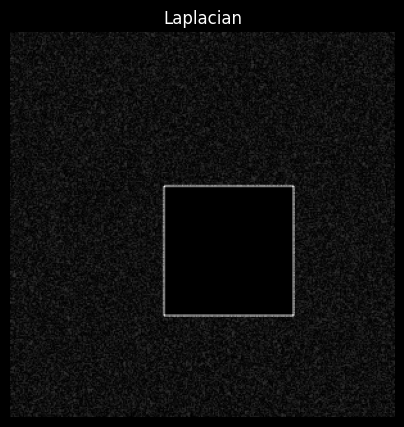

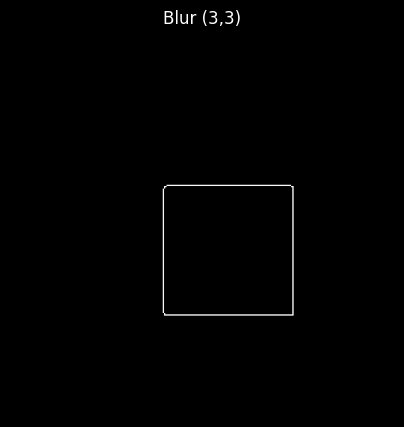

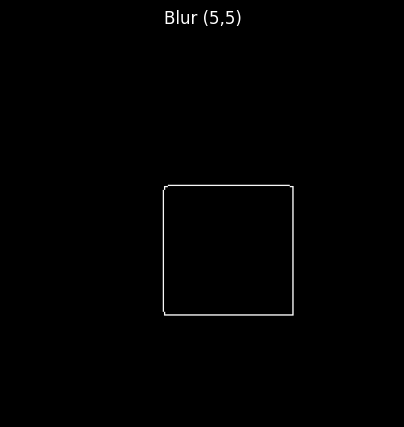

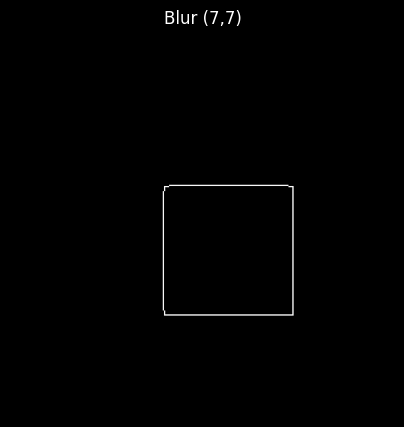

In [15]:
# Intermediate Tasks
noise = np.random.randint(0,30,img_square.shape,dtype=np.uint8)
noisy = cv2.add(img_square, noise)

canny = cv2.Canny(noisy,50,150)

sobel_x = cv2.Sobel(noisy,cv2.CV_64F,1,0,ksize=3)
sobel_y = cv2.Sobel(noisy,cv2.CV_64F,0,1,ksize=3)
sobel_mag = np.sqrt(sobelx**2 + sobely**2)

lap = cv2.Laplacian(noisy,cv2.CV_64F)

show(noisy,"Noisy Image")
show(canny,"Canny")
show(np.abs(sobel_mag),"Sobel")
show(np.abs(lap),"Laplacian")

blur3 = cv2.GaussianBlur(img_square,(3,3),0)
blur5 = cv2.GaussianBlur(img_square,(5,5),0)
blur7 = cv2.GaussianBlur(img_square,(7,7),0)

edges3 = cv2.Canny(blur3,50,150)
edges5 = cv2.Canny(blur5,50,150)
edges7 = cv2.Canny(blur7,50,150)

show(edges3,"Blur (3,3)")
show(edges5,"Blur (5,5)")
show(edges7,"Blur (7,7)")

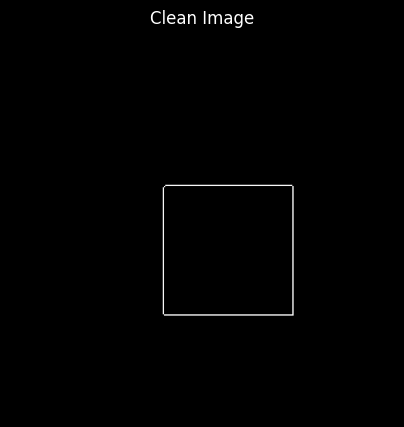

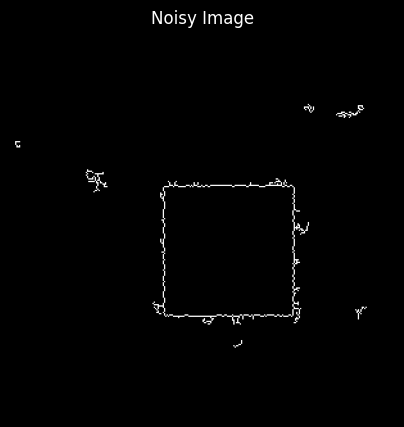

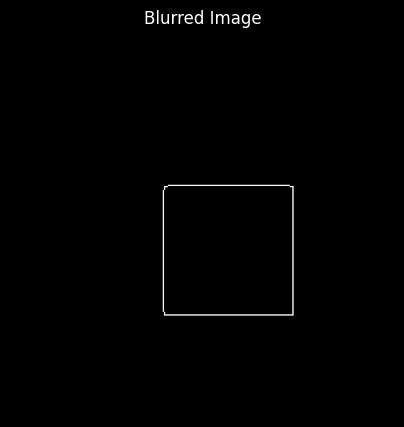

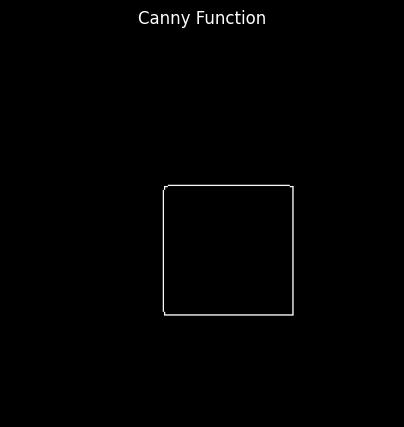

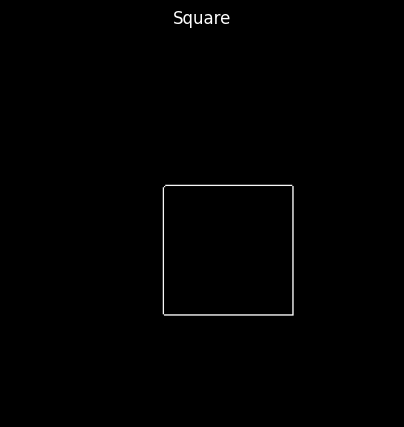

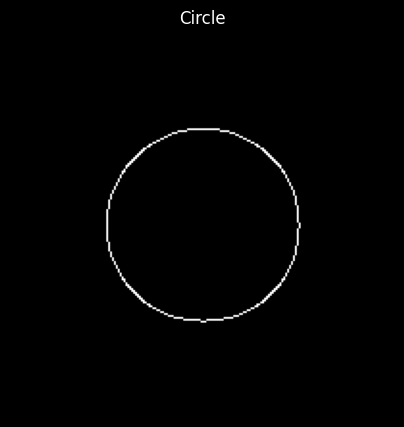

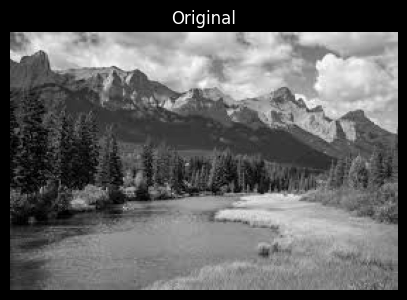

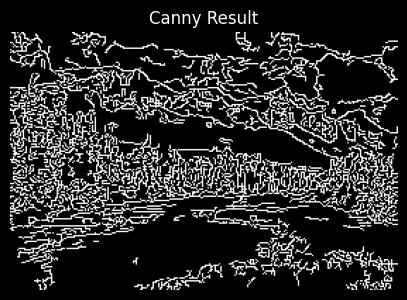

In [16]:
# Challenging Tasks
clean_edges = cv2.Canny(img_square,50,150)

noise = np.random.randint(0,30,img_square.shape,dtype=np.uint8)
noisy = cv2.add(img_square, noise)
noisy_edges = cv2.Canny(noisy,50,150)

blur = cv2.GaussianBlur(img_square,(5,5),0)
blur_edges = cv2.Canny(blur,50,150)

show(clean_edges,"Clean Image")
show(noisy_edges,"Noisy Image")
show(blur_edges,"Blurred Image")

def run_canny(image, low, high, blur=False):

    if blur:
        image = cv2.GaussianBlur(image,(5,5),0)

    edges = cv2.Canny(image, low, high)
    return edges

edges = run_canny(img_square,50,150,blur=True)
show(edges,"Canny Function")

edges_square = cv2.Canny(img_square,100,200)
edges_circle = cv2.Canny(img_circle,100,200)

show(edges_square,"Square")
show(edges_circle,"Circle")

real = cv2.imread("images/test_image_2.jpeg", cv2.IMREAD_GRAYSCALE)

edges = cv2.Canny(real,70,150)

show(real,"Original")
show(edges,"Canny Result")